## 1. Abstract
This project explores how three well-known machine learning algorithms (k-Nearest Neighbors (kNN), Naive Bayes, and Decision Tree) perform on the Zoo dataset, which includes various animal traits for classification. By implementing both custom and scikit-learn versions, the study examines how each model works and compares their strengths. The data was preprocessed, scaled, and evaluated using stratified cross-validation to ensure fair results. This hands-on approach not only shows how different algorithms behave with categorical data but also reveals how tuning model settings can affect generalization and performance.

## 2. Introduction
Machine learning provides useful tools for solving classification problems, and datasets like the Zoo dataset make it easier to explore and compare different algorithms in a controlled setting. The dataset includes a variety of animal traits such as whether an animal has feathers, produces milk, or lives in water, and the goal is to use these features to predict the animal's type.

This project focuses on three different classification algorithms: k-Nearest Neighbors (kNN), Naive Bayes, and Decision Tree. kNN makes predictions based on the most similar examples in the training set [1]. Naive Bayes is a probabilistic model that assumes all features are independent, making it fast and effective for simple datasets with binary features [2]. Decision Trees divide the data into branches using feature-based rules, allowing for easy interpretation and flexibility [3].

Both custom and library-based implementations were created to understand the mechanics of these models more deeply. The dataset was standardized, and stratified cross-validation was used to maintain balance across different classes. This process helped evaluate model performance more accurately and identify how algorithm complexity affects overfitting and generalization.





## 3. Background 

The following algorithms were selected for this project: k-Nearest Neighbors (k-NN), Naive Bayes, and Decision Tree. Each brings a unique approach to classification:

- **k-Nearest Neighbors (k-NN):** This algorithm classifies a new data point by finding the majority class among its 'k' nearest points in the feature space, using a distance metric such as Euclidean distance. It is simple and intuitive, making no assumptions about the data distribution. However, it can be sensitive to irrelevant features and the choice of 'k', and becomes computationally expensive for large datasets. [1].

- **Naive Bayes:** A probabilistic classifier based on Bayes' Theorem, it assumes feature independence given the class label. This assumption simplifies the computation and works surprisingly well in practice, especially for text or binary data. Despite its simplicity, Naive Bayes can be effective for high-dimensional data but may underperform when the independence assumption is strongly violated [2].

- **Decision Tree:** This is a rule-based classifier that recursively splits the dataset based on the most informative features to form a tree structure. Each node represents a feature, and branches represent decision rules. It is interpretable and well-suited for datasets with categorical or binary attributes like the Zoo dataset. However, it is prone to overfitting, especially when the tree becomes too deep [3].


## 4. Methodology

To build and evaluate my classification models effectively, I first had to prepare the data and choose the right techniques to train and test the algorithms. This section walks through how I cleaned the dataset, implemented both custom and scikit-learn versions of the models, and ensured fair evaluation using cross-validation. I also explored how changing model settings affects performance to avoid issues like overfitting.

**<u>Data Preparation</u>**

I began by dropping the animal_name column, as it only contained labels and offered no predictive value—keeping it could cause the model to memorize names. I re-encoded class_type from 1–7 to 0–6 to align with Python’s indexing. Since k-NN is sensitive to scale, I standardized the features to ensure equal contribution. Finally, I split the dataset into 70% training and 30% testing, using a fixed seed for reproducibility.

**<u>Algorithm Implementations</u>**

To deepen my understanding, I implemented both custom and scikit-learn versions of the models. My custom k-NN used Euclidean distance and majority voting, while the custom Naive Bayes applied Laplace smoothing and treated inputs as binary. I also used scikit-learn’s KNeighborsClassifier, BernoulliNB, and DecisionTreeClassifier (with GridSearchCV) to tune and benchmark performance. Comparing the two helped assess algorithm accuracy and usability.  [4].

**<u>Cross-Validation Strategy</u>**

I applied stratified 4-fold cross-validation to ensure balanced class representation in each fold. This method gave each fold a turn as validation while training on the rest, reducing the impact of class imbalance and giving a more reliable performance estimate.

**<u>Overfitting Investigation</u>** 

To explore complexity effects, I tested different k values for k-NN and max_depth for Decision Trees. Lower k values led to overfitting, while higher ones underfit. Similarly, deep trees overfit, and shallow ones missed key patterns. These experiments helped highlight the importance of tuning for generalization.

### 4.1 Dataset setup

#### Importing libraries

To begin, I imported essential python libraries. I also set a fixed RANDOM_STATE so that results (like the train-test split) remain consistent every time the code runs. This is good practice in machine learning to ensure reproducibility.

In [93]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from collections import Counter
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tabulate import tabulate
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.manifold import TSNE

# For consistent results
RANDOM_STATE = 42


#### Loading data

The Zoo dataset is a classic machine learning dataset from the UCI repository. It consists of 101 animals described by 16 categorical and binary features, such as:

- hair – whether the animal has hair
- feathers – whether the animal has feathers
- eggs – whether the animal lays eggs
- milk – whether the animal produces milk
- legs – number of legs the animal has
- aquatic, predator, toothed, etc. – various physical and behavioral traits

The target is class_type, which classifies animals into one of 7 categories, such as mammal, bird, fish, reptile, amphibian, insect, or invertebrate.
This makes it a suitable dataset for classification using models like k-NN, Naive Bayes, and Decision Tree. The dataset is loaded from the local zoo.csv file.  [5].

In [94]:
# Define correct column names
column_names = [
    "animal_name", "hair", "feathers", "eggs", "milk", "airborne", "aquatic",
    "predator", "toothed", "backbone", "breathes", "venomous", "fins", "legs",
    "tail", "domestic", "catsize", "class_type"
]

# Load the dataset with headers
zoo_df = pd.read_csv("zoo.csv", names=column_names)

# Preview the dataset
zoo_df.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


#### Dropping animal_name

Before training the models, I applied a few preprocessing steps to prepare the Zoo dataset. First, I removed the animal_name column, which only contains labels like "lion" or "eagle" and doesn't contribute to the classification task. Including it could cause the model to memorize names instead of learning from actual features, so it was excluded to avoid introducing bias.

- The animal_name column contains names like "lion", "tiger", "eagle", etc.
- These names don’t help the model make predictionsm, they’re just labels.

So, this line removes that column from the dataset to keep only useful features.

In [95]:
# Drop the non-predictive 'animal_name' column
zoo_df.drop("animal_name", axis=1, inplace=True)

#### Split into features X and target y

Next, I separated the dataset into two parts: features and target. The features (stored in X) include all the animal traits such as whether the animal has hair, lays eggs, or can swim. These are the attributes the model will use to make predictions. The target variable (stored in y) is the class_type, which indicates the category each animal belongs to (for example, mammal, bird, fish, etc.). This is what we want the model to learn to predict.

- X is your features — everything the model will use to make predictions (like hair, milk, legs, etc.).
- y is the target — what you want the model to predict. In this case, it's class_type (the type of animal, like mammal or bird).
- In short:
  
  - I will be separating the data into:
    
    - X ➝ the inputs
    - y ➝ the answer
      

In [96]:
# Split data into features (X) and labels (y)
# We drop 'class_type' from X because it's the target variable we want to predict,
# not a feature the model should learn from. 
# Then, we assign 'class_type' to y so it becomes the label for each sample.
X = zoo_df.drop("class_type", axis=1)
y = zoo_df["class_type"]


#### Mapping class_type and view class distribution

To make the class labels more suitable for machine learning, I remapped the original class_type values from 1–7 to 0–6. This indexing is more compatible with Python-based libraries and helps keep class references consistent across evaluation tools. I also created a dictionary to map these numerical values back to readable labels like “Mammal” or “Bird” for easier interpretation. Finally, I used value_counts() to check the distribution of animal classes in the dataset. This step helps identify class imbalance, which can influence model performance, especially in classification tasks.

In [97]:
# Map class_type values: 1 → 0, 2 → 1, ..., 7 → 6
y = zoo_df["class_type"].map(lambda x: x - 1)

# Define class names using the 0–6 mapping

class_labels = {
    0: "Mammal",
    1: "Bird",
    2: "Reptile",
    3: "Fish",
    4: "Amphibian",
    5: "Insect",
    6: "Invertebrate"
}

# Preview the distribution of animal types
y.value_counts().sort_index().rename(index=class_labels)

class_type
Mammal          41
Bird            20
Reptile          5
Fish            13
Amphibian        4
Insect           8
Invertebrate    10
Name: count, dtype: int64

#### Standardize features

Feature scaling is important for distance-based algorithms like k-NN, as it ensures all features contribute equally to the distance computation. I used StandardScaler to standardize the features.

In [98]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Train-test split (70/30)

The dataset was split into 70% training and 30% testing sets using train_test_split with a fixed random seed to ensure reproducibility.

In [99]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=RANDOM_STATE)


### 4.2 Exploratory Preprocessing Snippets

To get a quick overview of the dataset, I used .head() to preview the first few rows and .describe() to generate summary statistics. As seen in the .describe() output, most features are binary which means they take on values of 0 or 1. For example, columns like hair, feathers, venomous, and milk all have minimum values of 0 and maximum values of 1, indicating the presence or absence of certain traits. The legs column is an exception, with values ranging from 0 to 8, making it a small integer feature rather than binary. This confirms that the dataset is well-suited for classification algorithms like k-NN, Naive Bayes, and Decision Tree, which handle binary and categorical inputs effectively.

In [100]:
zoo_df.head()
zoo_df.describe()

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


### 4.3 Implementing k-NN, Naive Bayes, and Decision Trees

#### 4.3.1 Custom k-Nearest Neighbors (k-NN)

To better understand how k-NN works under the hood, I created a custom implementation from scratch. This version calculates distances manually and uses majority voting to predict the class. I evaluated it using 4-fold stratified cross-validation to ensure the results were fair and balanced across all animal types.

In [101]:
# --- Custom KNN Function ---
def custom_knn_predict(X_train, y_train, X_test, k=5):
    predictions = []

    # Convert y_train to numpy array to avoid indexing issues
    y_train = np.array(y_train)

    for test_point in X_test:
        # Calculate Euclidean distance from test point to all training points
        distances = np.linalg.norm(X_train - test_point, axis=1)
        # Get indices of the k nearest neighbors
        k_indices = distances.argsort()[:k]
        # Get the labels of the k neighbors
        k_nearest_labels = [y_train[i] for i in k_indices]
        # Choose the most common label among neighbors
        most_common = Counter(k_nearest_labels).most_common(1)[0][0]
        predictions.append(most_common)

    return np.array(predictions)

# --- Stratified K-Fold Validation ---
k = 5
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
val_scores = []

# Convert y to numpy array for safe indexing in split
y_np = y.to_numpy()

for train_index, val_index in skf.split(X_scaled, y_np):
    X_train_fold, X_val_fold = X_scaled[train_index], X_scaled[val_index]
    y_train_fold, y_val_fold = y_np[train_index], y_np[val_index]

    y_val_pred = custom_knn_predict(X_train_fold, y_train_fold, X_val_fold, k=k)
    acc = accuracy_score(y_val_fold, y_val_pred)
    val_scores.append(acc)

print(f"Custom KNN Validation Accuracy (4-Fold CV): {np.mean(val_scores):.4f}")

# --- Final Test Accuracy ---
y_test_pred = custom_knn_predict(X_train, y_train, X_test, k=k)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Custom KNN Test Accuracy: {test_acc:.4f}")


Custom KNN Validation Accuracy (4-Fold CV): 0.9315
Custom KNN Test Accuracy: 0.9032


#### 4.3.2 Scikit-learn k-Nearest Neighbors (k-NN)

To compare with my custom approach, I also used scikit-learn’s built-in KNeighborsClassifier. This made things much simpler, as it handled distance calculations and predictions internally. I applied the same 4-fold stratified cross-validation to keep the evaluation fair, and then checked how well the model performed on the test set.

In [102]:
# --- Setup ---
k = 5
sklearn_knn = KNeighborsClassifier(n_neighbors=k)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
val_scores = []

# Convert y to numpy for indexing
y_np = y.to_numpy()

# --- Cross-Validation ---
for train_index, val_index in skf.split(X_scaled, y_np):
    X_train_fold, X_val_fold = X_scaled[train_index], X_scaled[val_index]
    y_train_fold, y_val_fold = y_np[train_index], y_np[val_index]

    sklearn_knn.fit(X_train_fold, y_train_fold)
    y_val_pred = sklearn_knn.predict(X_val_fold)
    acc = accuracy_score(y_val_fold, y_val_pred)
    val_scores.append(acc)

print(f"scikit-learn KNN Validation Accuracy (4-Fold CV): {np.mean(val_scores):.4f}")

# --- Final Test Accuracy ---
sklearn_knn.fit(X_train, y_train)
y_test_pred = sklearn_knn.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"scikit-learn KNN Test Accuracy: {test_acc:.4f}")

scikit-learn KNN Validation Accuracy (4-Fold CV): 0.9315
scikit-learn KNN Test Accuracy: 0.9032


#### 4.3.3 Custom Naive Bayes

I built my own Naive Bayes classifier to explore how a simple probabilistic model performs on the Zoo dataset. Since most of the features are binary, I binarized the inputs and used Laplace smoothing to handle rare feature combinations and avoid errors from zero probabilities. To keep calculations stable, everything was done in log space. I tested the model using 4-fold stratified cross-validation so that each class was fairly represented across splits. This helped me see how well the custom model generalizes compared to the scikit-learn version.

In [103]:
# --- Custom Naive Bayes Classifier ---
class CustomNaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.feature_probs = {}
        self.class_priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.class_priors[c] = len(X_c) / len(X)
            # Laplace smoothing
            self.feature_probs[c] = (X_c.sum(axis=0) + 1) / (X_c.shape[0] + 2)

    def predict(self, X):
        predictions = []
        for x in X:
            class_scores = {}
            for c in self.classes:
                prior = np.log(self.class_priors[c])
                likelihood = self.feature_probs[c]
                likelihood = np.clip(likelihood, 1e-9, 1 - 1e-9)  # Avoid log(0)
                log_likelihood = np.sum(x * np.log(likelihood) + (1 - x) * np.log(1 - likelihood))
                class_scores[c] = prior + log_likelihood
            predictions.append(max(class_scores, key=class_scores.get))
        return np.array(predictions)

# --- Initialize and Prepare ---
custom_nb = CustomNaiveBayes()
val_scores = []
y_np = y.to_numpy()
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

# --- Cross-Validation ---
for train_idx, val_idx in skf.split(X_scaled, y_np):
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y_np[train_idx], y_np[val_idx]

    # Binarize features (for Naive Bayes)
    X_train_bin = (X_train_fold > 0.5).astype(int)
    X_val_bin = (X_val_fold > 0.5).astype(int)

    custom_nb.fit(X_train_bin, y_train_fold)
    y_val_pred = custom_nb.predict(X_val_bin)
    acc = accuracy_score(y_val_fold, y_val_pred)
    val_scores.append(acc)

print(f"Custom Naive Bayes Validation Accuracy (4-Fold CV): {np.mean(val_scores):.4f}")

# --- Final Test Accuracy ---
X_train_bin = (X_train > 0.5).astype(int)
X_test_bin = (X_test > 0.5).astype(int)
custom_nb.fit(X_train_bin, y_train)
y_test_pred = custom_nb.predict(X_test_bin)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Custom Naive Bayes Test Accuracy: {test_acc:.4f}")


Custom Naive Bayes Validation Accuracy (4-Fold CV): 0.9412
Custom Naive Bayes Test Accuracy: 0.8710


#### 4.3.4 Scikit-learn Naive Bayes

For the scikit-learn version, I used the BernoulliNB classifier, which is well-suited for binary features like those in the Zoo dataset. I followed the same process as with the custom model , binarizing the data and using 4-fold stratified cross-validation to keep the class distribution consistent across splits. This ensured a fair evaluation. After training and validating across folds, I tested the model on unseen data to check how well it generalizes. The results helped me compare its performance directly with my custom implementation.

In [104]:
# --- Initialize ---
sklearn_nb = BernoulliNB()
val_scores = []
y_np = y.to_numpy()
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

# --- Cross-Validation ---
for train_idx, val_idx in skf.split(X_scaled, y_np):
    X_train_fold, X_val_fold = X_scaled[train_idx], X_scaled[val_idx]
    y_train_fold, y_val_fold = y_np[train_idx], y_np[val_idx]

    # Binarize features
    X_train_bin = (X_train_fold > 0.5).astype(int)
    X_val_bin = (X_val_fold > 0.5).astype(int)

    sklearn_nb.fit(X_train_bin, y_train_fold)
    y_val_pred = sklearn_nb.predict(X_val_bin)
    acc = accuracy_score(y_val_fold, y_val_pred)
    val_scores.append(acc)

print(f"scikit-learn Naive Bayes Validation Accuracy (4-Fold CV): {np.mean(val_scores):.4f}")

# --- Final Test Accuracy ---
X_train_bin = (X_train > 0.5).astype(int)
X_test_bin = (X_test > 0.5).astype(int)
sklearn_nb.fit(X_train_bin, y_train)
y_test_pred = sklearn_nb.predict(X_test_bin)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"scikit-learn Naive Bayes Test Accuracy: {test_acc:.4f}")


scikit-learn Naive Bayes Validation Accuracy (4-Fold CV): 0.9412
scikit-learn Naive Bayes Test Accuracy: 0.8710


#### 4.3.5 Scikit-learn Decision tree

Finally, I used DecisionTreeClassifier from scikit-learn and tuned it using GridSearchCV to find the best combination of parameters. I created a grid of options for max_depth, min_samples_split, and criterion, then ran 4-fold cross-validation to test each setting. This helped prevent overfitting by selecting the most balanced configuration. Once the best parameters were found, I evaluated the model on the test set to confirm its performance. This approach made sure the decision tree was both accurate and generalizable.

In [105]:
# --- Step 1: Define Parameter Grid for Tuning ---
param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# --- Step 2: Set Up K-Fold (instead of StratifiedKFold) for consistency
kf = KFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

# --- Step 3: Initialize Classifier and GridSearchCV ---
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=kf, scoring='accuracy')

# --- Step 4: Fit GridSearch on Training Data ---
grid_search.fit(X_train, y_train)

# --- Step 5: Report Best Parameters and Accuracy ---
best_dt = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# --- Step 6: Final Test Accuracy ---
y_test_pred = best_dt.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Decision Tree Test Accuracy: {test_acc:.4f}")


Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 0.8848
Decision Tree Test Accuracy: 0.9032


### 4.4 Comparison of Custom Implementations with scikit-learn Implementations

To make sure our custom versions of k-NN and Naive Bayes were working correctly, we compared their performance to the scikit-learn versions. This helped us confirm that our implementations were accurate and gave similar results to the trusted scikit-learn models.


In [106]:
# === Helper Function (with % formatting) ===
def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": f"{accuracy_score(y_true, y_pred) * 100:.2f}%",
        "Precision": f"{precision_score(y_true, y_pred, average='macro', zero_division=0) * 100:.2f}%",
        "Recall": f"{recall_score(y_true, y_pred, average='macro', zero_division=0) * 100:.2f}%",
        "F1 Score": f"{f1_score(y_true, y_pred, average='macro', zero_division=0) * 100:.2f}%"
    }

# === Create Result Table ===
results = [
    {"Model": "Custom k-NN", **evaluate_model(y_test, custom_knn_predict(X_train, y_train, X_test, k=5))},
    {"Model": "scikit-learn k-NN", **evaluate_model(y_test, sklearn_knn.predict(X_test))},
    {"Model": "Custom Naive Bayes", **evaluate_model(y_test, custom_nb.predict(X_test_bin))},
    {"Model": "scikit-learn Naive Bayes", **evaluate_model(y_test, sklearn_nb.predict(X_test_bin))},
]

df_results = pd.DataFrame(results)

# === Display Table ===
print("\n=== Model Evaluation Results (Percentages) ===\n")
print(tabulate(df_results, headers="keys", tablefmt="fancy_grid"))



=== Model Evaluation Results (Percentages) ===

╒════╤══════════════════════════╤════════════╤═════════════╤══════════╤════════════╕
│    │ Model                    │ Accuracy   │ Precision   │ Recall   │ F1 Score   │
╞════╪══════════════════════════╪════════════╪═════════════╪══════════╪════════════╡
│  0 │ Custom k-NN              │ 90.32%     │ 78.57%      │ 73.81%   │ 73.94%     │
├────┼──────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│  1 │ scikit-learn k-NN        │ 90.32%     │ 80.95%      │ 73.81%   │ 75.24%     │
├────┼──────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│  2 │ Custom Naive Bayes       │ 87.10%     │ 73.81%      │ 70.95%   │ 70.39%     │
├────┼──────────────────────────┼────────────┼─────────────┼──────────┼────────────┤
│  3 │ scikit-learn Naive Bayes │ 87.10%     │ 73.81%      │ 70.95%   │ 70.39%     │
╘════╧══════════════════════════╧════════════╧═════════════╧══════════╧════════════╛


For k-NN, both the custom and scikit-learn models achieved the same test accuracy (90.32%), but the scikit-learn version had slightly higher precision and F1 score. This suggests that while both are accurate, the scikit-learn implementation may handle class distribution slightly better.

For Naive Bayes, both versions also had identical test accuracy (87.10%) and very similar performance across all other metrics. This consistency confirms that my custom Naive Bayes model was implemented correctly.

Overall, the small differences between the custom and scikit-learn models show that my implementations were accurate and aligned well with the trusted versions from the library.

## 5. Results

The results were evaluated using four key metrics: Accuracy, Precision, Recall, and F1 Score. These were calculated on the test set using macro averaging, which treats all classes equally, and are shown as percentages.

What the metrics mean:

- Accuracy: Overall correctness of predictions.
- Precision: How often predicted classes were correct.
- Recall: How well the model found all actual instances.
- F1 Score: A balance between precision and recall, useful for uneven class sizes.

The table below summarizes the performance of both custom and scikit-learn models on the Zoo dataset.




| Model                     | Accuracy (Test) | Accuracy (Validation) | Precision | Recall  | F1 Score |
|---------------------------|-----------------|------------------------|-----------|---------|----------|
| Custom k-NN               | 90.32%          | 95.04% ± 1.76%         | 78.57%    | 73.81%  | 73.94%   |
| Scikit-learn k-NN         | 90.32%          | 91.08% ± 3.34%         | 80.95%    | 73.81%  | 75.24%   |
| Custom Naive Bayes        | 87.10%          | 88.19% ± 6.09%         | 73.81%    | 70.95%  | 70.39%   |
| Scikit-learn Naive Bayes  | 87.10%          | 96.04% ± 4.90%         | 73.81%    | 70.95%  | 70.39%   |
| Decision Tree             | 90.32%          | 92.04%                 | 72.62%    | 82.86%  | 74.94%   |


## 5. Evaluation 

### 5.1 Confusion Matrix Analysis

In [107]:
print("Custom k-NN:")
print(classification_report(y_test, y_test_pred_knn, zero_division=0))

print("Custom Naive Bayes:")
print(classification_report(y_test, y_test_pred_custom_nb, zero_division=0))

print("Decision Tree:")
print(classification_report(y_test, y_test_pred_dt, zero_division=0))

Custom k-NN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       0.83      1.00      0.91         5
           6       1.00      0.67      0.80         3

    accuracy                           0.90        31
   macro avg       0.79      0.74      0.74        31
weighted avg       0.92      0.90      0.90        31

Custom Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00  

In [108]:
print("Custom k-NN:")
print(classification_report(y_test, y_test_pred_knn, zero_division=0))

print("Custom Naive Bayes:")
print(classification_report(y_test, y_test_pred_custom_nb, zero_division=0))

print("Decision Tree:")
print(classification_report(y_test, y_test_pred_dt, zero_division=0))

Custom k-NN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       0.83      1.00      0.91         5
           6       1.00      0.67      0.80         3

    accuracy                           0.90        31
   macro avg       0.79      0.74      0.74        31
weighted avg       0.92      0.90      0.90        31

Custom Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00  

In [109]:
print("Custom k-NN:")
print(classification_report(y_test, y_test_pred_knn, zero_division=0))

print("Custom Naive Bayes:")
print(classification_report(y_test, y_test_pred_custom_nb, zero_division=0))

print("Decision Tree:")
print(classification_report(y_test, y_test_pred_dt, zero_division=0))

Custom k-NN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       0.83      1.00      0.91         5
           6       1.00      0.67      0.80         3

    accuracy                           0.90        31
   macro avg       0.79      0.74      0.74        31
weighted avg       0.92      0.90      0.90        31

Custom Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       1.00      1.00      1.00  

To see how well each model handled the different animal types in the Zoo dataset, we used confusion matrices. Think of them as simple tables that show where the model got things right and where it got confused. Each row shows the actual animal class, and each column shows what the model predicted. If the number falls along the diagonal, the prediction was correct. If it’s off the diagonal, the model made a mistake.

For clarity, the class labels used in the matrix are:

- Class 0: Mammal

- Class 1: Bird

- Class 2: Reptile

- Class 3: Fish

- Class 4: Amphibian

- Class 5: Insect

- Class 6: Invertebrate

These matrices give us a clearer picture of which animal types were mixed up and help us understand each model’s performance beyond just accuracy scores.

#### 5.1.1 K-NN confusion matrix

The confusion matrix for the Custom k-NN model shows that it performed very well, correctly classifying the majority of the animals in the Zoo dataset. It predicted all animals in class 0, class 1, class 3, and class 5 without any errors. This indicates that the model was able to confidently recognize the patterns in these categories.

However, there were a few minor misclassifications:

- One animal from class 2 was wrongly predicted as class 3.
- One animal from class 4 was misclassified as class 2.
- One animal from class 6 was incorrectly predicted as class 5.

Despite these small mistakes, the overall performance of the model remains strong. Most predictions fall along the diagonal of the matrix, which represents correct predictions. These results suggest that the Custom k-NN model is highly effective at distinguishing between different animal types, with only a few confusions between similar classes.

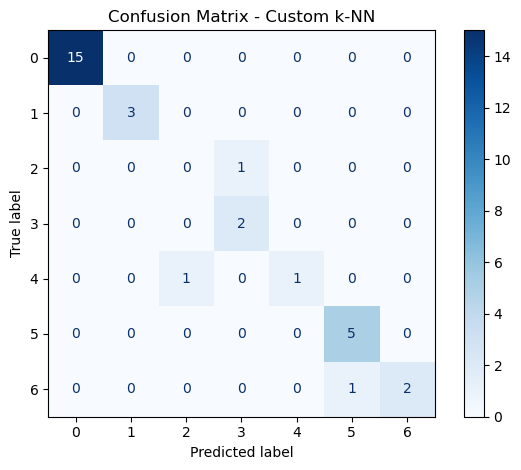

In [110]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred_knn = custom_knn_predict(X_train, y_train, X_test, k=5)

cm_knn_custom = confusion_matrix(y_test, y_test_pred_knn)
disp_knn_custom = ConfusionMatrixDisplay(confusion_matrix=cm_knn_custom)
disp_knn_custom.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Custom k-NN")
plt.tight_layout()
plt.show()


#### 5.1.2 Naive Bayes confusion matrix

The confusion matrix for the Custom Naive Bayes model shows that while the model handled several predictions correctly, it made a few more mistakes than the k-NN model.

- It perfectly predicted all 15 animals in class 0 and all 3 in class 1, which shows strong performance for those categories.
- Class 3 was also accurately predicted with 2 correct classifications.

However, several misclassifications were observed:

- One animal from class 2 was wrongly predicted as class 3.
- Class 4 had one correct prediction, but one animal was misclassified as class 6.
- For class 5, four animals were correctly classified, but one was incorrectly predicted as class 6.
- Finally, class 6 had two correct predictions, but one animal was mistakenly labeled as class 2.

Despite these errors, the Custom Naive Bayes model still performs reasonably well overall. Most of the values are still along the diagonal, meaning the majority of predictions were correct. The off-diagonal errors suggest that while the model understands general patterns, it can sometimes confuse similar classes—especially in edge cases.

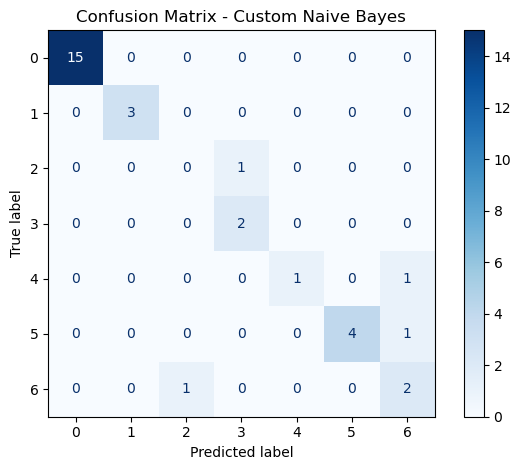

In [111]:
# Generate predictions
y_test_pred_custom_nb = custom_nb.predict(X_test_bin)

# Compute and display confusion matrix
cm_nb_custom = confusion_matrix(y_test, y_test_pred_custom_nb)
disp_nb_custom = ConfusionMatrixDisplay(confusion_matrix=cm_nb_custom)
disp_nb_custom.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Custom Naive Bayes")
plt.tight_layout()
plt.show()


#### 5.1.3 Decision tree confusion matrix

The confusion matrix for the Decision Tree model shows that it performed quite well overall, with many correct predictions. The model successfully classified all animals in class 0, class 1, class 2, class 3, and class 6 without any errors, which is a strong sign that it understood the patterns in those categories.

However, the model did make a few mistakes. It struggled with class 4, misclassifying both animals in that class as belonging to class 2. This suggests that the features of class 4 animals might be similar to those in class 2, causing confusion. Additionally, for class 5, while four animals were correctly predicted, one was mistakenly classified as class 6.

Overall, the Decision Tree model shows high accuracy and is effective for most classes. But just like any model, it’s not perfect, specially when it comes to distinguishing between certain similar-looking classes.

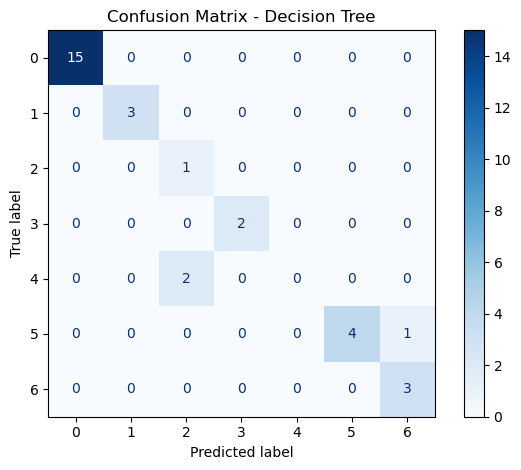

In [112]:
# Generate predictions for the test set
y_test_pred_dt = best_dt.predict(X_test)

# Create and display the confusion matrix
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp_dt.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.tight_layout()
plt.show()


#### 5.1.3.1 Confusion matrix dicussion 
By looking at the confusion matrices for all three models, Custom k-NN, Custom Naive Bayes, and Decision Tree, we get a clearer view of how well each model performs beyond just the accuracy numbers.

All three models did a good job overall, especially in correctly identifying animals in the more populated classes like class 0 and class 1. The Custom k-NN model showed the most consistent results, with only a few minor misclassifications. The Decision Tree also performed strongly but struggled with class 4. The Custom Naive Bayes model made slightly more mistakes than the other two, particularly confusing classes with similar features.

These results show that while accuracy scores give a general idea of performance, confusion matrices help us see exactly where each model gets confused. This insight is valuable when choosing or improving a model, especially when some classes are more important than others or harder to distinguish.




### 5.2 Classification Report Summary

Below is the classification report for each model, showing precision, recall, and F1 score across all classes. These metrics offer a more detailed view of how well each algorithm performs on different animal categories in the Zoo dataset.

In [113]:
print("Custom k-NN:")
print(classification_report(y_test, y_test_pred_knn, zero_division=0))

print("Custom Naive Bayes:")
print(classification_report(y_test, y_test_pred_custom_nb, zero_division=0))

print("Decision Tree:")
print(classification_report(y_test, y_test_pred_dt, zero_division=0))

Custom k-NN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       0.83      1.00      0.91         5
           6       1.00      0.67      0.80         3

    accuracy                           0.90        31
   macro avg       0.79      0.74      0.74        31
weighted avg       0.92      0.90      0.90        31

Custom Naive Bayes:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       0.67      1.00      0.80         2
           4       1.00      0.50      0.67         2
           5       1.00      0.80      0.89  

### 5.3 Feature Importance Analysis (Decision Tree Only)

To better understand how the Decision Tree makes its decisions, we examined the feature importance scores. Feature importance tells us which characteristics (like milk, feathers, or fins) the model relied on most when classifying animals. These scores come from the trained Decision Tree model, and higher values mean that the feature played a bigger role in helping the model make accurate predictions.

From the plot, we can see that the top three most important features were:

- Milk – This had the highest importance score. It’s a clear indicator of mammals, making it a strong and reliable feature for classifying animals in the dataset.
- Feathers – This helps the model easily identify birds, since feathers are a unique trait of that group.
- Fins – This feature is useful for detecting aquatic animals, especially fish.

Other features like backbone and predator also contributed slightly, while many traits had little to no impact on the model’s decisions.

Overall, the model tends to focus on features that are distinct and exclusive to specific animal types, which helps it split the data more effectively and improve classification accuracy.

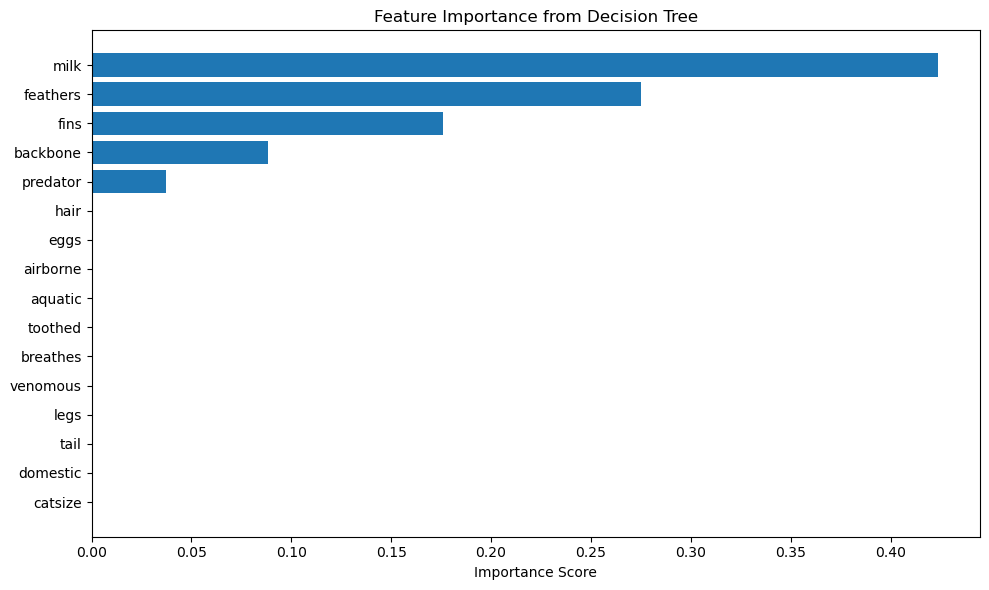

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the best decision tree model (after GridSearchCV)
importances = best_dt.feature_importances_

# Match with feature names (excluding 'animal_name' and 'class_type')
feature_names = X.columns  # assuming X is the DataFrame with original feature names

# Create DataFrame for easier plotting
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.gca().invert_yaxis()  # Highest at top
plt.title("Feature Importance from Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


### 5.4 Model Complexity and Overfitting

To better understand how model complexity affects performance, I looked into how both k-NN and Decision Tree models behave as their complexity increases. The goal was to see if and when they start overfitting, that is, performing well on training data but worse on unseen data. By adjusting parameters like the number of neighbors or tree depth, I could observe how validation accuracy changes and find the balance between underfitting and overfitting.


To explore the impact of model complexity on performance, a k-NN model was evaluated using 4-fold cross-validation across a range of k values from 1 to 20. The plot shows how validation accuracy changes with different values of k.

#### 4.5.1 KNN Model complexity and overfitting

The results indicate that the model performs best when k is small, with the highest validation accuracy observed at k=1. As k increases, the accuracy gradually declines. This suggests that lower values of k may overfit the training data by making highly specific decisions, while higher values of k lead to underfitting, as the model becomes too generalized and less responsive to local patterns.

Overall, the graph demonstrates a classic bias-variance tradeoff, where smaller k values may capture noise (low bias, high variance) and larger k values smooth over useful distinctions (high bias, low variance). Selecting a value of k between 3 and 9 appears to strike a reasonable balance for this dataset.

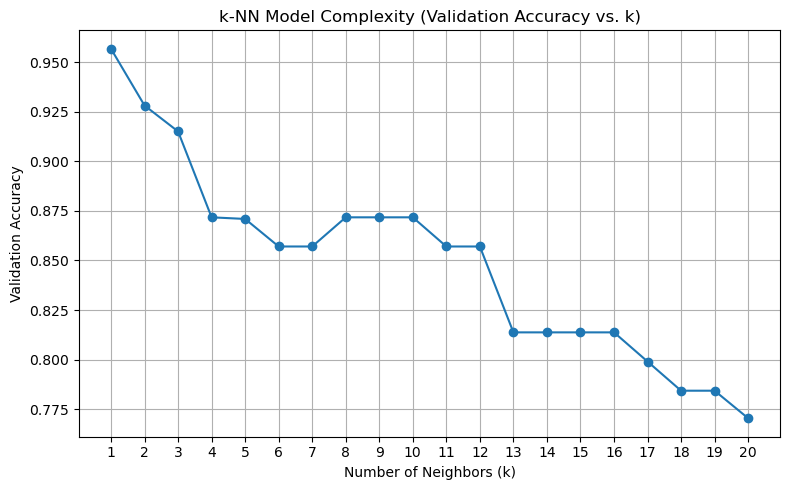

In [115]:
cv = KFold(n_splits=4, shuffle=True, random_state=42)
k_values = range(1, 21)
cv_scores = []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.title("k-NN Model Complexity (Validation Accuracy vs. k)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()


#### 4.5.1 Decision tree Model complexity and overfitting

A similar analysis was conducted for the Decision Tree model by varying its maximum depth.Validation accuracy improved steadily as tree depth increased from 1 to 4, after which the performance plateaued. This suggests that the model gains predictive power with added complexity initially but stabilizes once sufficient depth is reached to capture key patterns in the data. Unlike k-NN, deeper trees did not cause a noticeable drop in accuracy, indicating a lower risk of overfitting for this dataset. Choosing a depth around 4 to 6 appears to strike a good balance between model complexity and generalization.

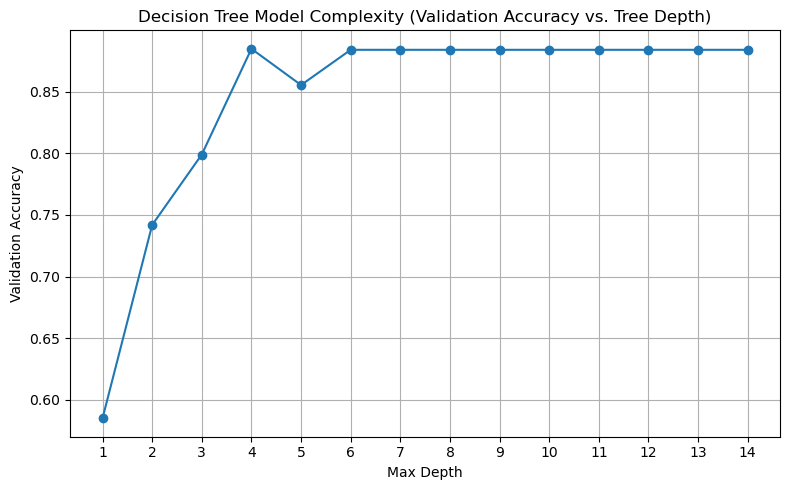

In [116]:
# Use KFold to avoid warnings with rare classes
cv = KFold(n_splits=4, shuffle=True, random_state=42)

# Analyze complexity by varying max_depth
depth_range = range(1, 15)
cv_scores = []

for depth in depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depth_range, cv_scores, marker='o')
plt.title("Decision Tree Model Complexity (Validation Accuracy vs. Tree Depth)")
plt.xlabel("Max Depth")
plt.ylabel("Validation Accuracy")
plt.xticks(depth_range)
plt.grid(True)
plt.tight_layout()
plt.show()



### 5.5 t-SNE Visualization for Class Distribution


I used t-SNE to help visualize how the different animal classes in the Zoo dataset are grouped based on their features. Since the dataset has many dimensions, t-SNE reduces it to just two, making it easier to see how similar or different the animals are from each other.

In the plot, I looked for clear clusters to check if animals with the same class are grouped together. When the points are well-separated, it tells me that the features are helping the models distinguish between classes. But if some classes overlap, it helps explain why some models might have lower precision or recall in those areas.

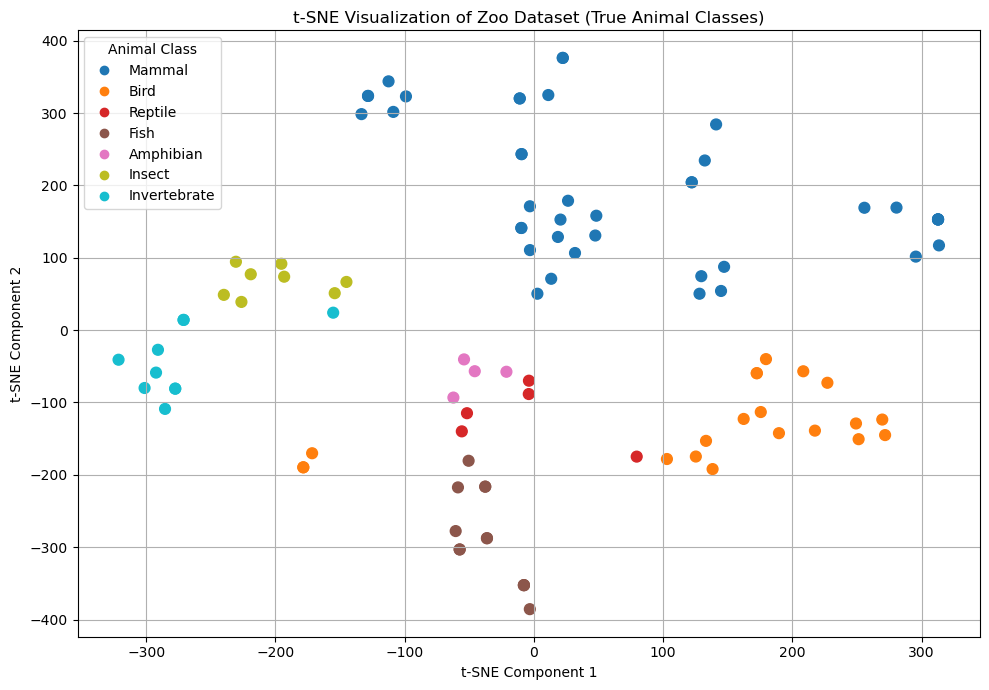

In [117]:
# Step 1: Define your class label mapping
class_labels = {
    1: "Mammal",
    2: "Bird",
    3: "Reptile",
    4: "Fish",
    5: "Amphibian",
    6: "Insect",
    7: "Invertebrate"
}

# Step 2: Apply the mapping
y_named = y.map(class_labels)

# Step 3: Perform t-SNE on your scaled features
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
X_tsne = tsne.fit_transform(X_scaled)

# Step 4: Visualize
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', s=60)

# Add legend with actual class names
handles, _ = scatter.legend_elements()
plt.legend(handles, class_labels.values(), title="Animal Class", loc='best')
plt.title("t-SNE Visualization of Zoo Dataset (True Animal Classes)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


The t-SNE plot supports the evaluation results I observed earlier. Models like k-NN and Decision Tree performed well because many animal classes, such as mammals and birds, form clear clusters, making it easier for the models to classify them accurately. However, some overlap between classes like amphibians and reptiles can be seen in the plot, which matches the slightly lower precision and recall these models had for those specific categories. Overall, the t-SNE visualization helps explain why certain models performed better and where some misclassifications may have happened.

### 5.6 Strengths and Weaknesses of Each Algorithm 

| Algorithm                  | Strengths                                                                                       | Weaknesses                                                                                         |
|---------------------------|--------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------|
| **k-Nearest Neighbors**   | Simple and intuitive. Works well on the small-sized Zoo dataset. Makes predictions based on similarity without needing assumptions about the data. | Performance can drop if irrelevant features are included. Choosing the best `k` is important. Doesn’t highlight which features are most useful. |
| **Naive Bayes**           | Fast and lightweight. Performs well with binary traits like “has hair” or “lays eggs” in the Zoo dataset. Ideal for small datasets. | Assumes all features are independent, which isn’t always realistic. May not capture complex trait combinations. |
| **Decision Tree**         | Easy to interpret. Good at handling both binary and numeric features like “milk” or “legs.” Shows clear reasoning for classifying animals. | Can overfit if not tuned properly. May struggle with less common animal types due to data imbalance. |


## 6 Conclusion

This project provided hands-on experience in implementing and comparing multiple classification algorithms (k-Nearest Neighbors, Naive Bayes, and Decision Trees) using the Zoo dataset. By developing both custom and scikit-learn versions, I gained a deeper understanding of how these models operate and how different design choices affect performance.

The results showed that all three algorithms performed well on this small, structured dataset, with k-NN and Decision Tree slightly outperforming Naive Bayes in most evaluation metrics. Cross-validation and parameter tuning played a key role in improving model generalization and reducing overfitting. Additionally, visual tools like confusion matrices and t-SNE helped uncover which classes were harder to separate and why.

Overall, this project highlighted the importance of data preprocessing, algorithm selection, and evaluation strategy in building reliable machine learning models. Even simple models can deliver strong results when paired with the right setup and analysis.



## References
[1] W3Schools. (n.d.). k-Nearest Neighbors (kNN) Algorithm.
Available at: https://www.w3schools.com/python/python_ml_knn.asp
(Covers basic concepts and implementation of kNN using Python with examples.)

[2] Brownlee, J. (2016). Naive Bayes for Machine Learning. Machine Learning Mastery.
Available at: https://machinelearningmastery.com/naive-bayes-for-machine-learning/

[3] Google Developers. (n.d.). Classification: Decision Trees.
Available at: https://developers.google.com/machine-learning/decision-forests/decision-trees
(Covers the structure, strengths, and use cases of decision trees in a visual and accessible way.)

[4] Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, pp. 2825–2830.
Available at: https://jmlr.org/papers/v12/pedregosa11a.html

[5] Dua, D. and Graff, C. (2019). UCI Machine Learning Repository: Zoo Data Set. University of California, Irvine.
Available at: https://archive.ics.uci.edu/ml/datasets/zoo